# Notebook 06: Peer Based Synthetic Progression and Dynamic Reassessment

This notebook evaluates how predicted academic risk may change after intervention support.

### Experimental assumption

For the thesis experiment, each predicted at risk student uses **only the Rank 1 proposed intervention from Notebook 05**.

This is a controlled experimental assumption. In the later prototype, the mentor will be able to select one or multiple intervention plans from the database.

### Main method

1. Take the student's Rank 1 intervention.
2. Identify a broader set of current features that the intervention could plausibly influence.
3. Find real not at risk training peers, preferably from the same programme and year level.
4. Randomly sample one real peer for each simulation.
5. Move the intervention related features toward that same peer profile.
6. Use three study defined progression strengths: 25%, 50%, and 75%.
7. Run 100 simulations per student per scenario.
8. Validate joint realism using nearest neighbour distance.
9. Reassess every synthetic profile using the frozen calibrated model.
10. Report absolute and relative risk reduction, uncertainty, plausibility, and threshold crossing.

The simulation is scenario analysis. It does not estimate causal intervention effects.

The simulation is implemented using batched model prediction and plausibility checks for computational efficiency.


## 1. Imports and paths

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42
N_SIMULATIONS = 100
MIN_PEER_POOL = 10

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATA_DIR = PROJECT_DIR / "data" / "processed" / "ml_ready"
MODEL_DIR = PROJECT_DIR / "results" / "final_model"
INTERVENTION_DIR = PROJECT_DIR / "results" / "interventions"
OUTPUT_DIR = PROJECT_DIR / "results" / "reassessment"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(RANDOM_STATE)

## 2. Load the frozen model, data, and Notebook 05 outputs

In [2]:
final_model = joblib.load(MODEL_DIR / "final_calibrated_model.joblib")
with open(MODEL_DIR / "final_model_metadata.json", "r", encoding="utf-8") as file:
    metadata = json.load(file)

X_train = pd.read_pickle(DATA_DIR / "X_train_raw.pkl")
y_train = pd.read_pickle(DATA_DIR / "y_train.pkl")
X_test = pd.read_pickle(DATA_DIR / "X_test_raw.pkl")
FINAL_THRESHOLD = float(metadata["final_threshold"])
RAW_FEATURES = list(metadata["selected_features"])
mentor_options = pd.read_csv(INTERVENTION_DIR / "mentor_proposed_intervention_options.csv")

assert len(RAW_FEATURES) == 24
assert list(X_test.columns) == RAW_FEATURES
print("Training students:", len(X_train))
print("Test students:", len(X_test))
print("Rank 1 intervention cases:", len(mentor_options))
print("Simulations per scenario:", N_SIMULATIONS)

Training students: 3008
Test students: 752
Rank 1 intervention cases: 225
Simulations per scenario: 100


## 3. Rank 1 intervention used for the experiment

The highest ranked proposed intervention from Notebook 05 is treated as the selected intervention only for thesis evaluation.

**Prototype later:** mentor reviews the options → selects one or multiple interventions → database stores the plan → reassessment uses the actual selected plan.

In [3]:
experiment_cases = mentor_options[[
    "case_id",
    "predicted_risk_probability",
    "highest_priority_proposed_intervention",
]].rename(columns={
    "highest_priority_proposed_intervention": "selected_rank1_intervention"
})

display(experiment_cases.head())
print("Experimental cases:", len(experiment_cases))

,case_id,predicted_risk_probability,selected_rank1_intervention
0,TEST_CASE_0002,0.842991,Tutoring and academic support
1,TEST_CASE_0012,0.725048,Tutoring and academic support
2,TEST_CASE_0014,0.716895,Tutoring and academic support
3,TEST_CASE_0021,0.908958,Tutoring and academic support
4,TEST_CASE_0022,0.914817,Tutoring and academic support


Experimental cases: 225


## 4. Intervention specific progression features

The intervention proposed in Notebook 05 is based on the student's full SHAP explanation.

For reassessment, historical factors are not changed directly. Instead, each intervention is linked to a broader set of **current behaviours that could plausibly improve during the progression period**.

This separates:

**why the intervention was proposed**  
from  
**which current indicators may change after support**.

The progression bundles are study specific modelling assumptions and are not interpreted as causal treatment effects.

In [4]:
INTERVENTION_FEATURES = {
    "Tutoring and academic support": [
        "assessment_interaction_events_ordinal",
        "learning_material_events_ordinal",
        "accessed_course_count",
        "course_access_rate",
        "total_course_event_clicks",
        "active_days_numeric",
        "active_days_rate",
    ],

    "Attendance support": [
        "attendance_rate",
        "absence_count",
        "active_days_numeric",
        "active_days_rate",
    ],

    "Moodle engagement support": [
        "accessed_course_count",
        "course_access_rate",
        "total_course_event_clicks",
        "active_days_numeric",
        "active_days_rate",
        "zero_activity_days",
        "largest_inactivity_days",
        "learning_material_events_ordinal",
        "assessment_interaction_events_ordinal",
    ],

    "Workload adjustment": [
        "registered_course_count",
        "registered_credits",
        "enrolled_course_count",
        "attendance_rate",
        "absence_count",
        "active_days_rate",
        "course_access_rate",
        "learning_material_events_ordinal",
        "assessment_interaction_events_ordinal",
    ],

    "Counselling or advisor referral": [
        "attendance_rate",
        "absence_count",
        "active_days_numeric",
        "active_days_rate",
        "zero_activity_days",
        "largest_inactivity_days",
        "learning_material_events_ordinal",
        "assessment_interaction_events_ordinal",
    ],
}

rules_table = pd.DataFrame([
    {
        "intervention": intervention,
        "feature_count": len(features),
        "simulated_features": " | ".join(features),
    }
    for intervention, features in INTERVENTION_FEATURES.items()
])

#display(rules_table)
with pd.option_context('display.max_colwidth', None):
    display(rules_table)

,intervention,feature_count,simulated_features
0,Tutoring and academic support,7,assessment_interaction_events_ordinal | learning_material_events_ordinal | accessed_course_count | course_access_rate | total_course_event_clicks | active_days_numeric | active_days_rate
1,Attendance support,4,attendance_rate | absence_count | active_days_numeric | active_days_rate
2,Moodle engagement support,9,accessed_course_count | course_access_rate | total_course_event_clicks | active_days_numeric | active_days_rate | zero_activity_days | largest_inactivity_days | learning_material_events_ordinal | assessment_interaction_events_ordinal
3,Workload adjustment,9,registered_course_count | registered_credits | enrolled_course_count | attendance_rate | absence_count | active_days_rate | course_access_rate | learning_material_events_ordinal | assessment_interaction_events_ordinal
4,Counselling or advisor referral,8,attendance_rate | absence_count | active_days_numeric | active_days_rate | zero_activity_days | largest_inactivity_days | learning_material_events_ordinal | assessment_interaction_events_ordinal


## 5. Real peer groups from training data only

Reference peers are **not at risk students from the training split only**.

Peer hierarchy:
1. same programme and same year level, if at least 10 peers exist,
2. otherwise same programme,
3. otherwise all not at risk training students.

Peers are sampled with replacement, so 100 simulations do not require 100 unique students.

In [5]:
CATEGORICAL_FEATURES = ["programme_or_school", "year_level", "previous_academic_standing"]
NUMERIC_FEATURES = [f for f in RAW_FEATURES if f not in CATEGORICAL_FEATURES]

not_at_risk_train = X_train.loc[np.asarray(y_train) == 0, RAW_FEATURES].reset_index(drop=True)
training_numeric = X_train[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce")
training_min = training_numeric.min(); training_max = training_numeric.max()

def get_peer_pool(student_row):
    same_program_year = not_at_risk_train[
        (not_at_risk_train["programme_or_school"] == student_row["programme_or_school"]) &
        (not_at_risk_train["year_level"] == student_row["year_level"])
    ]
    if len(same_program_year) >= MIN_PEER_POOL:
        return same_program_year, "Same programme and year level"
    same_program = not_at_risk_train[
        not_at_risk_train["programme_or_school"] == student_row["programme_or_school"]
    ]
    if len(same_program) >= MIN_PEER_POOL:
        return same_program, "Same programme"
    return not_at_risk_train, "All not at risk training students"

print("Not at risk training peers:", len(not_at_risk_train))

Not at risk training peers: 2262


## 6. Joint realism validation

A synthetic profile can be realistic feature by feature but still form an unusual combination.

To check joint plausibility, the training profiles are transformed into a common distance space.

Before calculating distance:

- missing numeric values are filled using the **training median**,
- missing categorical values are filled using the **training most frequent value**,
- numeric predictors are scaled to 0 to 1,
- categorical predictors are one hot encoded.

The imputation and transformation are fitted on the **training split only**, avoiding leakage from the held out test students.

Nearest neighbour distance is then calculated in the transformed space. The plausibility threshold is the 95th percentile of the second nearest neighbour distances among real training students.

A synthetic profile is flagged as plausible when its nearest real training neighbour is no farther away than this threshold.

In [6]:
try:
    one_hot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )
except TypeError:
    one_hot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
    )

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        MinMaxScaler(),
    ),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "onehot",
        one_hot,
    ),
])

plausibility_encoder = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            NUMERIC_FEATURES,
        ),
        (
            "cat",
            categorical_pipeline,
            CATEGORICAL_FEATURES,
        ),
    ]
)

plausibility_encoder.fit(
    X_train[RAW_FEATURES]
)

encoded_train = plausibility_encoder.transform(
    X_train[RAW_FEATURES]
)

assert not np.isnan(
    np.asarray(encoded_train, dtype=float)
).any()

plausibility_nn = NearestNeighbors(
    n_neighbors=2,
    metric="manhattan",
)

plausibility_nn.fit(
    encoded_train
)

real_distances = plausibility_nn.kneighbors(
    encoded_train,
    return_distance=True,
)[0][:, 1]

PLAUSIBILITY_THRESHOLD = float(
    np.quantile(
        real_distances,
        0.95,
    )
)

print(
    "Missing values after plausibility preprocessing:",
    int(
        np.isnan(
            np.asarray(
                encoded_train,
                dtype=float,
            )
        ).sum()
    ),
)

print(
    "Joint plausibility threshold:",
    round(
        PLAUSIBILITY_THRESHOLD,
        4,
    ),
)

Missing values after plausibility preprocessing: 0
Joint plausibility threshold: 2.5929


## 7. Peer based progression rule

For each student, the notebook samples **100 real not at risk peers once**.

The same 100 peers are reused for Conservative, Moderate, and Strong scenarios. This creates a paired progression experiment where only the progression strength changes.

For an intervention related feature \(j\):

\[
x'_{j}=x_j+\alpha_s(r_j-x_j)
\]

where:

- \(x_j\) is the student's current value,
- \(r_j\) is the value from the same sampled real peer,
- \(\alpha_s\) is 0.25, 0.50, or 0.75.

Progression is applied only when the peer value represents improvement for that feature.

Examples:

- attendance rate: higher is better,
- absence count: lower is better,
- active days: higher is better,
- zero activity days: lower is better,
- workload features: lower values represent the workload reduction assumption.

If the sampled peer is worse than the student on a feature, that feature remains unchanged.

The scenario strengths are study defined sensitivity assumptions, not empirical intervention effect sizes.

In [7]:
SCENARIOS = {
    "Conservative": 0.25,
    "Moderate": 0.50,
    "Strong": 0.75,
}

HIGHER_IS_BETTER = {
    "attendance_rate",
    "accessed_course_count",
    "course_access_rate",
    "total_course_event_clicks",
    "active_days_numeric",
    "active_days_rate",
    "learning_material_events_ordinal",
    "assessment_interaction_events_ordinal",
}

LOWER_IS_BETTER = {
    "absence_count",
    "zero_activity_days",
    "largest_inactivity_days",
    "registered_course_count",
    "registered_credits",
    "enrolled_course_count",
}

ROUND_FEATURES = {
    "registered_course_count",
    "registered_credits",
    "enrolled_course_count",
    "accessed_course_count",
    "total_course_event_clicks",
    "active_days_numeric",
    "zero_activity_days",
    "largest_inactivity_days",
    "learning_material_events_ordinal",
    "assessment_interaction_events_ordinal",
}

def is_beneficial_move(feature, current, peer_value):
    if feature in HIGHER_IS_BETTER:
        return peer_value > current

    if feature in LOWER_IS_BETTER:
        return peer_value < current

    return False

def create_synthetic_profile(
    student_row,
    peer_row,
    features,
    alpha,
):
    synthetic = student_row.copy()

    for feature in features:
        current = pd.to_numeric(
            pd.Series([student_row[feature]]),
            errors="coerce",
        ).iloc[0]

        peer_value = pd.to_numeric(
            pd.Series([peer_row[feature]]),
            errors="coerce",
        ).iloc[0]

        if pd.isna(current) or pd.isna(peer_value):
            continue

        if not is_beneficial_move(
            feature,
            current,
            peer_value,
        ):
            continue

        new_value = (
            current
            + alpha
            * (peer_value - current)
        )

        new_value = np.clip(
            new_value,
            training_min[feature],
            training_max[feature],
        )

        if feature in ROUND_FEATURES:
            new_value = round(new_value)

        synthetic[feature] = new_value

    return synthetic

## 8. Run 100 paired simulations per student

The same paired simulation methodology is retained, but the implementation is batched for speed.

For each student:

1. sample 100 real peers once,
2. reuse those peers across Conservative, Moderate, and Strong scenarios,
3. create all 300 synthetic profiles,
4. score all 300 profiles in **one model call**,
5. validate all 300 profiles in **one nearest neighbour call**.

This produces the same experimental design while avoiding thousands of slow single row model and distance calculations.

In [8]:
case_to_position = {
    f"TEST_CASE_{i + 1:04d}": i
    for i in range(len(X_test))
}

run_rows = []

for student_number, (_, case) in enumerate(
    experiment_cases.iterrows(),
    start=1,
):
    case_id = case["case_id"]

    student_row = X_test.iloc[
        case_to_position[case_id]
    ][RAW_FEATURES].copy()

    baseline_risk = float(
        case["predicted_risk_probability"]
    )

    intervention = case[
        "selected_rank1_intervention"
    ]

    features = INTERVENTION_FEATURES[
        intervention
    ]

    peer_pool, peer_rule = get_peer_pool(
        student_row
    )

    sampled_peer_positions = rng.integers(
        0,
        len(peer_pool),
        size=N_SIMULATIONS,
    )

    profiles = []
    profile_meta = []

    for run, peer_position in enumerate(
        sampled_peer_positions,
        start=1,
    ):
        peer = peer_pool.iloc[
            int(peer_position)
        ]

        for scenario, alpha in SCENARIOS.items():

            synthetic = create_synthetic_profile(
                student_row,
                peer,
                features,
                alpha,
            )

            profiles.append(synthetic)

            profile_meta.append({
                "scenario": scenario,
                "alpha": alpha,
                "simulation_run": run,
            })

    simulated_df = pd.DataFrame(
        profiles,
        columns=RAW_FEATURES,
    )

    # One model call for all 300 profiles.
    risks = final_model.predict_proba(
        simulated_df
    )[:, 1]

    # One plausibility transform and NN call for all 300 profiles.
    encoded_synthetic = (
        plausibility_encoder.transform(
            simulated_df
        )
    )

    distances = plausibility_nn.kneighbors(
        encoded_synthetic,
        n_neighbors=1,
        return_distance=True,
    )[0][:, 0]

    plausible = (
        distances
        <= PLAUSIBILITY_THRESHOLD
    )

    for meta, risk, distance, ok in zip(
        profile_meta,
        risks,
        distances,
        plausible,
    ):
        risk = float(risk)

        absolute_reduction = (
            baseline_risk - risk
        )

        relative_reduction_pct = (
            (
                absolute_reduction
                / baseline_risk
            )
            * 100
            if baseline_risk > 0
            else 0.0
        )

        run_rows.append({
            "case_id": case_id,
            "selected_rank1_intervention": intervention,
            "peer_rule": peer_rule,
            "peer_pool_size": len(peer_pool),
            "scenario": meta["scenario"],
            "alpha": meta["alpha"],
            "simulation_run": meta["simulation_run"],
            "baseline_risk_probability": baseline_risk,
            "reassessed_risk_probability": risk,
            "risk_reduction": absolute_reduction,
            "relative_risk_reduction_pct": relative_reduction_pct,
            "risk_reduced": bool(
                absolute_reduction > 0
            ),
            "nearest_training_distance": float(distance),
            "jointly_plausible": bool(ok),
            "below_final_threshold": bool(
                risk < FINAL_THRESHOLD
            ),
        })

    if (
        student_number % 25 == 0
        or student_number == len(experiment_cases)
    ):
        print(
            f"Completed {student_number}/"
            f"{len(experiment_cases)} students"
        )

simulation_runs = pd.DataFrame(
    run_rows
)

print(
    "Simulation rows:",
    len(simulation_runs),
)

print(
    "Expected:",
    len(experiment_cases)
    * len(SCENARIOS)
    * N_SIMULATIONS,
)

Completed 25/225 students
Completed 50/225 students
Completed 75/225 students
Completed 100/225 students
Completed 125/225 students
Completed 150/225 students
Completed 175/225 students
Completed 200/225 students
Completed 225/225 students
Simulation rows: 67500
Expected: 67500


## 9. Student level reassessment results

The main reassessment outcome is **risk reduction**, not only whether the student crosses the final 0.29 threshold.

For each student and scenario, the notebook reports:

- baseline risk,
- mean reassessed risk,
- absolute mean risk reduction,
- relative risk reduction percentage,
- percentage of simulations where risk decreased,
- 95% simulation interval,
- joint plausibility,
- threshold crossing as a secondary measure.

Relative risk reduction is:

\[
\text{Relative Risk Reduction}
=
\frac{P_{baseline}-P_{reassessed}}
{P_{baseline}}
\times 100
\]

The 0.29 threshold remains useful, but it was deliberately chosen for high recall, so meaningful improvement can occur without crossing it.

In [9]:
student_reassessment = (
    simulation_runs
    .groupby(
        [
            "case_id",
            "selected_rank1_intervention",
            "peer_rule",
            "peer_pool_size",
            "scenario",
            "alpha",
            "baseline_risk_probability",
        ],
        as_index=False,
    )
    .agg(
        mean_reassessed_risk=(
            "reassessed_risk_probability",
            "mean",
        ),
        mean_risk_reduction=(
            "risk_reduction",
            "mean",
        ),
        mean_relative_risk_reduction_pct=(
            "relative_risk_reduction_pct",
            "mean",
        ),
        pct_simulations_risk_reduced=(
            "risk_reduced",
            lambda x: x.mean() * 100,
        ),
        simulation_interval_lower=(
            "reassessed_risk_probability",
            lambda x: x.quantile(0.025),
        ),
        simulation_interval_upper=(
            "reassessed_risk_probability",
            lambda x: x.quantile(0.975),
        ),
        pct_below_threshold=(
            "below_final_threshold",
            lambda x: x.mean() * 100,
        ),
        pct_jointly_plausible=(
            "jointly_plausible",
            lambda x: x.mean() * 100,
        ),
    )
)

scenario_order = [
    "Conservative",
    "Moderate",
    "Strong",
]

student_reassessment[
    "scenario"
] = pd.Categorical(
    student_reassessment["scenario"],
    categories=scenario_order,
    ordered=True,
)

student_reassessment = (
    student_reassessment
    .sort_values(
        [
            "case_id",
            "scenario",
        ]
    )
)

print(
    "Student scenario summaries:",
    len(student_reassessment),
)

Student scenario summaries: 675


## 10. Mentor progress status for follow up

The reassessment layer should help the mentor decide whether a student's **average reassessed risk is reliably improving**.

The earlier version used the full 95% range of individual simulation outcomes. That interval was too strict for progress classification because even a few unfavourable peer simulations could make the interval cross zero.

This version instead uses a **95% bootstrap confidence interval for the mean risk reduction** for each student and scenario.

Progress status is defined as:

- **Improving:** the lower bound of the 95% bootstrap confidence interval is above 0.
- **No clear progress:** the confidence interval includes 0.
- **Worsening:** the upper bound of the confidence interval is below 0.

The separate `pct_simulations_risk_reduced` measure is retained as a consistency indicator showing how often the simulated progression reduced risk.

This progress status is a mentor decision support indicator and does not replace mentor judgement.

In [10]:
BOOTSTRAP_RUNS = 2000
bootstrap_rng = np.random.default_rng(RANDOM_STATE)

bootstrap_rows = []

for (case_id, scenario), group in simulation_runs.groupby(
    ["case_id", "scenario"]
):

    reductions = (
        group["risk_reduction"]
        .to_numpy()
    )

    bootstrap_means = np.array([
        bootstrap_rng.choice(
            reductions,
            size=len(reductions),
            replace=True,
        ).mean()
        for _ in range(BOOTSTRAP_RUNS)
    ])

    ci_lower, ci_upper = np.quantile(
        bootstrap_means,
        [0.025, 0.975],
    )

    bootstrap_rows.append({
        "case_id": case_id,
        "scenario": scenario,
        "mean_risk_reduction_ci_lower": float(ci_lower),
        "mean_risk_reduction_ci_upper": float(ci_upper),
    })

student_bootstrap_ci = pd.DataFrame(
    bootstrap_rows
)

student_reassessment = student_reassessment.merge(
    student_bootstrap_ci,
    on=["case_id", "scenario"],
    how="left",
)

def progress_status(row):

    if row["mean_risk_reduction_ci_lower"] > 0:
        return "Improving"

    if row["mean_risk_reduction_ci_upper"] < 0:
        return "Worsening"

    return "No clear progress"

student_reassessment[
    "progress_status"
] = student_reassessment.apply(
    progress_status,
    axis=1,
)

student_reassessment[
    "mentor_follow_up"
] = student_reassessment[
    "progress_status"
].map({
    "Improving":
        "Continue intervention and monitor progress",
    "No clear progress":
        "Review progress and consider adjusting support",
    "Worsening":
        "Review intervention plan and consider alternative support",
})

progress_distribution = (
    student_reassessment
    .groupby(
        [
            "scenario",
            "progress_status",
        ],
        observed=True,
    )
    .size()
    .rename("students")
    .reset_index()
)

progress_distribution[
    "percentage"
] = (
    progress_distribution
    .groupby("scenario")[
        "students"
    ]
    .transform(
        lambda x:
            x / x.sum() * 100
    )
)

display(
    progress_distribution
    .sort_values(
        [
            "scenario",
            "progress_status",
        ]
    )
    .round(2)
)

,scenario,progress_status,students,percentage
0,Conservative,Improving,156,69.33
1,Conservative,No clear progress,33,14.67
2,Conservative,Worsening,36,16.00
3,Moderate,Improving,181,80.44
4,Moderate,No clear progress,25,11.11
5,Moderate,Worsening,19,8.44
6,Strong,Improving,195,86.67
7,Strong,No clear progress,14,6.22
8,Strong,Worsening,16,7.11


## 11. Three anonymised sample cases with different Rank 1 interventions

Three examples are selected automatically to demonstrate variety.

The notebook chooses the three most common Rank 1 intervention types, then selects a representative student near the median baseline risk within each intervention group.

Each displayed case therefore has a **different Rank 1 intervention**.

In [11]:
intervention_counts = (
    experiment_cases[
        "selected_rank1_intervention"
    ]
    .value_counts()
)

sample_interventions = (
    intervention_counts
    .head(3)
    .index
    .tolist()
)

sample_case_rows = []

for intervention in sample_interventions:

    group = (
        experiment_cases[
            experiment_cases[
                "selected_rank1_intervention"
            ] == intervention
        ]
        .sort_values(
            "predicted_risk_probability"
        )
        .reset_index(drop=True)
    )

    representative = group.iloc[
        len(group) // 2
    ]

    sample_case_rows.append(
        representative
    )

sample_cases_table = pd.DataFrame(
    sample_case_rows
)

SAMPLE_CASES = (
    sample_cases_table[
        "case_id"
    ]
    .tolist()
)

display(
    sample_cases_table[
        [
            "case_id",
            "selected_rank1_intervention",
            "predicted_risk_probability",
        ]
    ]
)

sample_results = (
    student_reassessment[
        student_reassessment[
            "case_id"
        ].isin(SAMPLE_CASES)
    ][
        [
            "case_id",
            "selected_rank1_intervention",
            "scenario",
            "baseline_risk_probability",
            "mean_reassessed_risk",
            "mean_risk_reduction",
            "mean_relative_risk_reduction_pct",
            "pct_simulations_risk_reduced",
            "mean_risk_reduction_ci_lower",
            "mean_risk_reduction_ci_upper",
            "simulation_interval_lower",
            "simulation_interval_upper",
            "pct_below_threshold",
            "pct_jointly_plausible",
            "progress_status",
            "mentor_follow_up",
        ]
    ]
)

display(
    sample_results.style.format({
        "baseline_risk_probability": "{:.3f}",
        "mean_reassessed_risk": "{:.3f}",
        "mean_risk_reduction": "{:.3f}",
        "mean_relative_risk_reduction_pct": "{:.1f}%",
        "pct_simulations_risk_reduced": "{:.1f}%",
        "mean_risk_reduction_ci_lower": "{:.3f}",
        "mean_risk_reduction_ci_upper": "{:.3f}",
        "simulation_interval_lower": "{:.3f}",
        "simulation_interval_upper": "{:.3f}",
        "pct_below_threshold": "{:.1f}%",
        "pct_jointly_plausible": "{:.1f}%",
    })
)

,case_id,selected_rank1_intervention,predicted_risk_probability
101,TEST_CASE_0046,Tutoring and academic support,0.865758
11,TEST_CASE_0456,Workload adjustment,0.598770
0,TEST_CASE_0357,Moodle engagement support,0.425312


,case_id,selected_rank1_intervention,scenario,baseline_risk_probability,mean_reassessed_risk,mean_risk_reduction,mean_relative_risk_reduction_pct,pct_simulations_risk_reduced,mean_risk_reduction_ci_lower,mean_risk_reduction_ci_upper,simulation_interval_lower,simulation_interval_upper,pct_below_threshold,pct_jointly_plausible,progress_status,mentor_follow_up
39,TEST_CASE_0046,Tutoring and academic support,Conservative,0.866,0.866,-0.000,-0.0%,6.0%,-0.001,0.001,0.842,0.873,0.0%,100.0%,No clear progress,Review progress and consider adjusting support
40,TEST_CASE_0046,Tutoring and academic support,Moderate,0.866,0.864,0.002,0.2%,9.0%,-0.001,0.005,0.803,0.878,0.0%,97.0%,No clear progress,Review progress and consider adjusting support
41,TEST_CASE_0046,Tutoring and academic support,Strong,0.866,0.860,0.005,0.6%,29.0%,0.002,0.009,0.785,0.877,0.0%,95.0%,Improving,Continue intervention and monitor progress
339,TEST_CASE_0357,Moodle engagement support,Conservative,0.425,0.371,0.054,12.8%,65.0%,0.041,0.069,0.234,0.429,16.0%,100.0%,Improving,Continue intervention and monitor progress
340,TEST_CASE_0357,Moodle engagement support,Moderate,0.425,0.343,0.082,19.3%,67.0%,0.063,0.103,0.102,0.441,19.0%,100.0%,Improving,Continue intervention and monitor progress
341,TEST_CASE_0357,Moodle engagement support,Strong,0.425,0.312,0.113,26.7%,79.0%,0.091,0.139,0.064,0.431,29.0%,100.0%,Improving,Continue intervention and monitor progress
423,TEST_CASE_0456,Workload adjustment,Conservative,0.599,0.488,0.111,18.5%,99.0%,0.103,0.118,0.418,0.597,0.0%,100.0%,Improving,Continue intervention and monitor progress
424,TEST_CASE_0456,Workload adjustment,Moderate,0.599,0.472,0.127,21.2%,99.0%,0.116,0.139,0.362,0.540,1.0%,100.0%,Improving,Continue intervention and monitor progress
425,TEST_CASE_0456,Workload adjustment,Strong,0.599,0.467,0.132,22.1%,99.0%,0.113,0.151,0.238,0.537,7.0%,100.0%,Improving,Continue intervention and monitor progress


## 12. Sample progression diagram

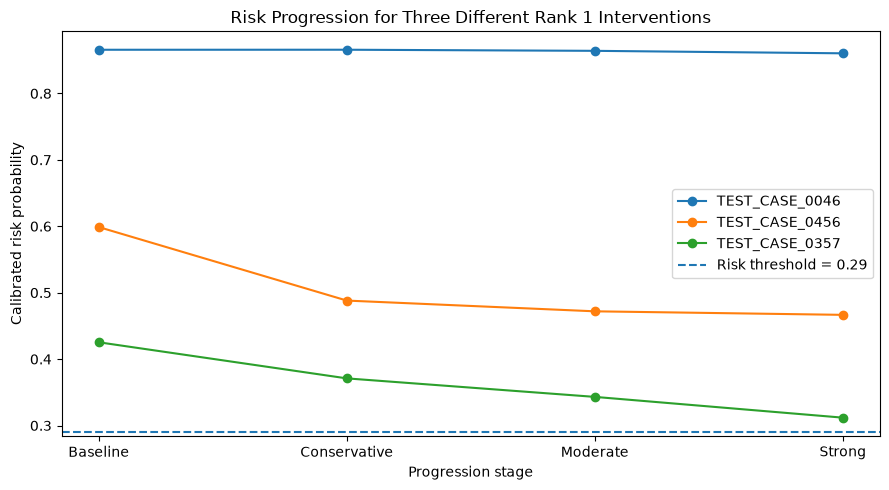

In [12]:
progression_order = ["Baseline", "Conservative", "Moderate", "Strong"]
plt.figure(figsize=(9,5))
for case_id in SAMPLE_CASES:
    rows = student_reassessment[student_reassessment["case_id"] == case_id].sort_values("scenario")
    baseline = float(rows["baseline_risk_probability"].iloc[0])
    values = [baseline, *rows["mean_reassessed_risk"].tolist()]
    plt.plot(progression_order, values, marker="o", label=case_id)
plt.axhline(FINAL_THRESHOLD, linestyle="--", label=f"Risk threshold = {FINAL_THRESHOLD:.2f}")
plt.xlabel("Progression stage"); plt.ylabel("Calibrated risk probability")
plt.title("Risk Progression for Three Different Rank 1 Interventions")
plt.legend(); plt.tight_layout()
SAMPLE_FIGURE = FIGURES_DIR / "sample_student_risk_progression.png"
plt.savefig(SAMPLE_FIGURE, dpi=300, bbox_inches="tight")
plt.show()

## 13. Mentor follow up summary

This table converts the reassessment outputs into a concise mentor facing follow up view.

It shows:

- selected Rank 1 intervention,
- baseline risk,
- reassessed risk,
- progress status,
- percentage of simulations with reduced risk,
- joint plausibility,
- recommended follow up action.

The action is a **system suggestion for review**, not an automatic intervention decision.

In [13]:
mentor_follow_up_table = (
    student_reassessment[
        [
            "case_id",
            "selected_rank1_intervention",
            "scenario",
            "baseline_risk_probability",
            "mean_reassessed_risk",
            "mean_relative_risk_reduction_pct",
            "mean_risk_reduction_ci_lower",
            "mean_risk_reduction_ci_upper",
            "pct_simulations_risk_reduced",
            "pct_jointly_plausible",
            "progress_status",
            "mentor_follow_up",
        ]
    ]
    .sort_values(
        [
            "case_id",
            "scenario",
        ]
    )
)

display(
    mentor_follow_up_table.head(15).style.format({
        "baseline_risk_probability": "{:.3f}",
        "mean_reassessed_risk": "{:.3f}",
        "mean_relative_risk_reduction_pct": "{:.1f}%",
        "mean_risk_reduction_ci_lower": "{:.3f}",
        "mean_risk_reduction_ci_upper": "{:.3f}",
        "pct_simulations_risk_reduced": "{:.1f}%",
        "pct_jointly_plausible": "{:.1f}%",
    })
)

,case_id,selected_rank1_intervention,scenario,baseline_risk_probability,mean_reassessed_risk,mean_relative_risk_reduction_pct,mean_risk_reduction_ci_lower,mean_risk_reduction_ci_upper,pct_simulations_risk_reduced,pct_jointly_plausible,progress_status,mentor_follow_up
0,TEST_CASE_0002,Tutoring and academic support,Conservative,0.843,0.843,0.0%,-0.000,0.001,16.0%,100.0%,No clear progress,Review progress and consider adjusting support
1,TEST_CASE_0002,Tutoring and academic support,Moderate,0.843,0.840,0.4%,-0.000,0.008,14.0%,93.0%,No clear progress,Review progress and consider adjusting support
2,TEST_CASE_0002,Tutoring and academic support,Strong,0.843,0.833,1.2%,0.003,0.018,16.0%,89.0%,Improving,Continue intervention and monitor progress
3,TEST_CASE_0012,Tutoring and academic support,Conservative,0.725,0.713,1.7%,0.009,0.016,97.0%,100.0%,Improving,Continue intervention and monitor progress
4,TEST_CASE_0012,Tutoring and academic support,Moderate,0.725,0.694,4.3%,0.027,0.035,97.0%,100.0%,Improving,Continue intervention and monitor progress
5,TEST_CASE_0012,Tutoring and academic support,Strong,0.725,0.684,5.7%,0.037,0.046,97.0%,100.0%,Improving,Continue intervention and monitor progress
6,TEST_CASE_0014,Tutoring and academic support,Conservative,0.717,0.710,1.0%,0.002,0.014,26.0%,100.0%,Improving,Continue intervention and monitor progress
7,TEST_CASE_0014,Tutoring and academic support,Moderate,0.717,0.693,3.4%,0.009,0.041,28.0%,100.0%,Improving,Continue intervention and monitor progress
8,TEST_CASE_0014,Tutoring and academic support,Strong,0.717,0.666,7.1%,0.028,0.075,35.0%,100.0%,Improving,Continue intervention and monitor progress
9,TEST_CASE_0021,Tutoring and academic support,Conservative,0.909,0.909,0.0%,0.000,0.001,35.0%,100.0%,Improving,Continue intervention and monitor progress


## 14. Overall reassessment summary and progression diagram

The overall results focus primarily on risk reduction.

Threshold crossing is retained as a secondary measure because the 0.29 operational threshold was selected to prioritise recall.

Stronger scenarios are not forced to reduce risk for every student. Nonmonotonic behaviour is retained because the Random Forest can respond nonlinearly.

,scenario,students,mean_baseline_risk,mean_reassessed_risk,mean_risk_reduction,mean_relative_risk_reduction_pct,mean_pct_simulations_risk_reduced,mean_pct_below_threshold,mean_pct_jointly_plausible
0,Conservative,225,0.76,0.7450,0.0150,2.4169,50.8622,1.7067,86.6622
1,Moderate,225,0.76,0.7321,0.0279,4.2594,58.1200,2.9733,85.0489
2,Strong,225,0.76,0.7204,0.0396,5.5867,61.8444,4.1644,81.5556


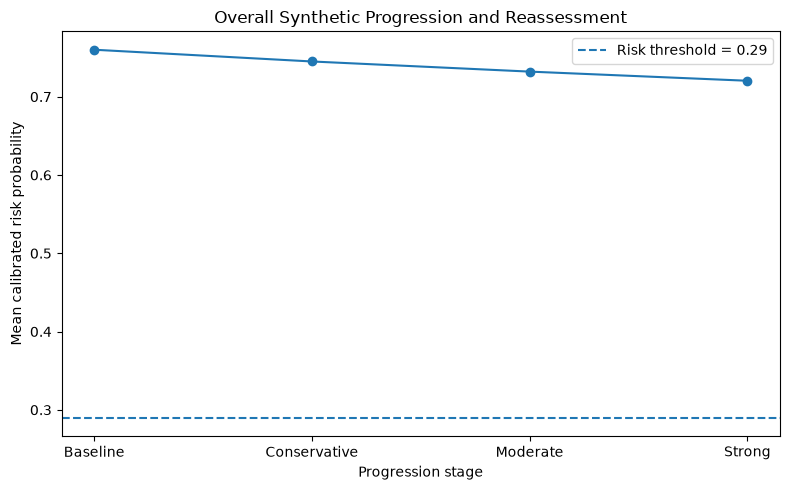

In [14]:
overall_summary = (
    student_reassessment
    .groupby(
        "scenario",
        observed=True,
        as_index=False,
    )
    .agg(
        students=(
            "case_id",
            "nunique",
        ),
        mean_baseline_risk=(
            "baseline_risk_probability",
            "mean",
        ),
        mean_reassessed_risk=(
            "mean_reassessed_risk",
            "mean",
        ),
        mean_risk_reduction=(
            "mean_risk_reduction",
            "mean",
        ),
        mean_relative_risk_reduction_pct=(
            "mean_relative_risk_reduction_pct",
            "mean",
        ),
        mean_pct_simulations_risk_reduced=(
            "pct_simulations_risk_reduced",
            "mean",
        ),
        mean_pct_below_threshold=(
            "pct_below_threshold",
            "mean",
        ),
        mean_pct_jointly_plausible=(
            "pct_jointly_plausible",
            "mean",
        ),
    )
)

display(
    overall_summary.round(4)
)

plt.figure(
    figsize=(8, 5)
)

baseline_mean = float(
    experiment_cases[
        "predicted_risk_probability"
    ].mean()
)

plt.plot(
    [
        "Baseline",
        "Conservative",
        "Moderate",
        "Strong",
    ],
    [
        baseline_mean,
        *overall_summary[
            "mean_reassessed_risk"
        ].tolist(),
    ],
    marker="o",
)

plt.axhline(
    FINAL_THRESHOLD,
    linestyle="--",
    label=(
        f"Risk threshold = "
        f"{FINAL_THRESHOLD:.2f}"
    ),
)

plt.xlabel(
    "Progression stage"
)

plt.ylabel(
    "Mean calibrated risk probability"
)

plt.title(
    "Overall Synthetic Progression and Reassessment"
)

plt.legend()
plt.tight_layout()

OVERALL_FIGURE = (
    FIGURES_DIR
    / "overall_reassessment_progression.png"
)

plt.savefig(
    OVERALL_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 15. Robustness: monotonic progression check

Because the same 100 peers are now used across Conservative, Moderate, and Strong scenarios, scenario comparisons are paired.

For each student, the expected mean ordering is:

**Conservative risk ≥ Moderate risk ≥ Strong risk**

The Random Forest is nonlinear, so the model is not forced to obey this relationship. Any remaining nonmonotonic cases are reported as robustness evidence rather than removed.

In [15]:
risk_wide = student_reassessment.pivot(index="case_id", columns="scenario", values="mean_reassessed_risk")
monotonic = (
    (risk_wide["Conservative"] >= risk_wide["Moderate"]) &
    (risk_wide["Moderate"] >= risk_wide["Strong"])
)
nonmonotonic_cases = risk_wide.loc[~monotonic].reset_index()
print("Total students:", len(risk_wide))
print("Monotonic progression:", int(monotonic.sum()))
print("Nonmonotonic cases:", int((~monotonic).sum()))
print("Nonmonotonic percentage:", f"{(~monotonic).mean()*100:.2f}%")

Total students: 225
Monotonic progression: 184
Nonmonotonic cases: 41
Nonmonotonic percentage: 18.22%


## 16. Reassessment evaluation metrics for the thesis

The reassessment layer is a key contribution of the framework, so it is evaluated using several complementary measures.

### Primary effectiveness measures

- **Mean reassessed risk:** average predicted risk after simulated progression.
- **Mean absolute risk reduction:** baseline risk minus reassessed risk.
- **Mean relative risk reduction:** percentage reduction relative to baseline.
- **Students with mean risk reduction:** percentage of students whose mean reassessed risk is lower than baseline.
- **Simulation consistency:** average percentage of simulations in which risk decreased.
- **95% bootstrap confidence interval for mean risk reduction:** uncertainty around the cohort level reduction.

### Robustness and validity measures

- **Joint plausibility:** percentage of synthetic profiles close to real training profiles.
- **Monotonic progression:** percentage of students whose mean risk decreases from Conservative to Moderate to Strong.

### Secondary operational measure

- **Threshold crossing:** percentage of simulations or students falling below the final 0.29 decision threshold.

Threshold crossing is secondary because the threshold was deliberately selected to prioritise recall. A student can show meaningful improvement without crossing 0.29.

In [16]:
BOOTSTRAP_RUNS = 2000
bootstrap_rng = np.random.default_rng(RANDOM_STATE)

evaluation_rows = []

for scenario in scenario_order:

    scenario_data = student_reassessment[
        student_reassessment["scenario"] == scenario
    ].copy()

    reductions = (
        scenario_data[
            "mean_risk_reduction"
        ]
        .to_numpy()
    )

    bootstrap_means = np.array([
        bootstrap_rng.choice(
            reductions,
            size=len(reductions),
            replace=True,
        ).mean()
        for _ in range(BOOTSTRAP_RUNS)
    ])

    ci_lower, ci_upper = np.quantile(
        bootstrap_means,
        [0.025, 0.975],
    )

    evaluation_rows.append({
        "scenario": scenario,
        "students": len(scenario_data),
        "mean_baseline_risk": scenario_data[
            "baseline_risk_probability"
        ].mean(),
        "mean_reassessed_risk": scenario_data[
            "mean_reassessed_risk"
        ].mean(),
        "mean_absolute_risk_reduction": reductions.mean(),
        "mean_relative_risk_reduction_pct": scenario_data[
            "mean_relative_risk_reduction_pct"
        ].mean(),
        "pct_students_mean_risk_reduced": (
            (reductions > 0).mean() * 100
        ),
        "mean_pct_simulations_risk_reduced": scenario_data[
            "pct_simulations_risk_reduced"
        ].mean(),
        "risk_reduction_ci_lower": ci_lower,
        "risk_reduction_ci_upper": ci_upper,
        "mean_pct_jointly_plausible": scenario_data[
            "pct_jointly_plausible"
        ].mean(),
        "mean_pct_below_threshold": scenario_data[
            "pct_below_threshold"
        ].mean(),
    })

reassessment_evaluation = pd.DataFrame(
    evaluation_rows
)

display(
    reassessment_evaluation.round(4)
)

,scenario,students,mean_baseline_risk,mean_reassessed_risk,mean_absolute_risk_reduction,mean_relative_risk_reduction_pct,pct_students_mean_risk_reduced,mean_pct_simulations_risk_reduced,risk_reduction_ci_lower,risk_reduction_ci_upper,mean_pct_jointly_plausible,mean_pct_below_threshold
0,Conservative,225,0.76,0.7450,0.0150,2.4169,75.5556,50.8622,0.0103,0.0201,86.6622,1.7067
1,Moderate,225,0.76,0.7321,0.0279,4.2594,87.5556,58.1200,0.0208,0.0355,85.0489,2.9733
2,Strong,225,0.76,0.7204,0.0396,5.5867,91.5556,61.8444,0.0295,0.0501,81.5556,4.1644


## 17. Future prototype reassessment

The thesis experiment uses one Rank 1 intervention for consistency.

The prototype will use:

**Proposed options → mentor selects one or multiple interventions → database stores final plan → later Banner and Moodle snapshot is loaded → the same frozen model reassesses risk.**

At a real later snapshot, all 24 predictors can be refreshed from institutional data rather than generated synthetically.

## 18. Reassessment evaluation for mentor follow up

The reassessment layer is evaluated primarily as a **student progress monitoring and mentor decision support layer**.

The key metrics are:

1. **Progress Detection Rate**  
   Percentage of students classified as Improving using the 95% bootstrap confidence interval of mean risk reduction.

2. **No Clear Progress Rate**  
   Percentage of students whose confidence interval includes 0.

3. **Worsening Rate**  
   Percentage of students whose confidence interval is entirely below 0.

4. **Progression Sensitivity**  
   Percentage of students whose mean risk follows the expected ordering from Conservative to Moderate to Strong.

5. **Progress Consistency**  
   Mean percentage of simulations where risk is reduced.

6. **Joint Plausibility**  
   Mean percentage of synthetic profiles that remain close to observed training profiles.

7. **Risk reduction magnitude and uncertainty**  
   Retained as supporting evidence, including the bootstrap confidence interval.

These metrics evaluate whether the reassessment layer can detect, differentiate, and communicate student progression for mentor follow up.

In [17]:
mentor_evaluation_rows = []

for scenario in scenario_order:

    scenario_data = student_reassessment[
        student_reassessment["scenario"] == scenario
    ].copy()

    status_counts = (
        scenario_data[
            "progress_status"
        ]
        .value_counts()
    )

    total = len(
        scenario_data
    )

    mentor_evaluation_rows.append({
        "scenario": scenario,
        "students": total,

        "progress_detection_rate_pct":
            status_counts.get(
                "Improving",
                0,
            )
            / total
            * 100,

        "no_clear_progress_rate_pct":
            status_counts.get(
                "No clear progress",
                0,
            )
            / total
            * 100,

        "worsening_rate_pct":
            status_counts.get(
                "Worsening",
                0,
            )
            / total
            * 100,

        "mean_pct_simulations_risk_reduced":
            scenario_data[
                "pct_simulations_risk_reduced"
            ].mean(),

        "mean_pct_jointly_plausible":
            scenario_data[
                "pct_jointly_plausible"
            ].mean(),

        "mean_relative_risk_reduction_pct":
            scenario_data[
                "mean_relative_risk_reduction_pct"
            ].mean(),

        "mean_bootstrap_ci_width":
            (
                scenario_data[
                    "mean_risk_reduction_ci_upper"
                ]
                - scenario_data[
                    "mean_risk_reduction_ci_lower"
                ]
            ).mean(),
    })

mentor_reassessment_evaluation = pd.DataFrame(
    mentor_evaluation_rows
)

display(
    mentor_reassessment_evaluation.round(2)
)

,scenario,students,progress_detection_rate_pct,no_clear_progress_rate_pct,worsening_rate_pct,mean_pct_simulations_risk_reduced,mean_pct_jointly_plausible,mean_relative_risk_reduction_pct,mean_bootstrap_ci_width
0,Conservative,225,69.33,14.67,16.00,50.86,86.66,2.42,0.01
1,Moderate,225,80.44,11.11,8.44,58.12,85.05,4.26,0.01
2,Strong,225,86.67,6.22,7.11,61.84,81.56,5.59,0.02


## 19. Progress status distribution

This diagram shows how many students are classified as Improving, No clear progress, or Worsening under each scenario.

It provides a direct visual summary of the reassessment layer's ability to identify student progression for mentor follow up.

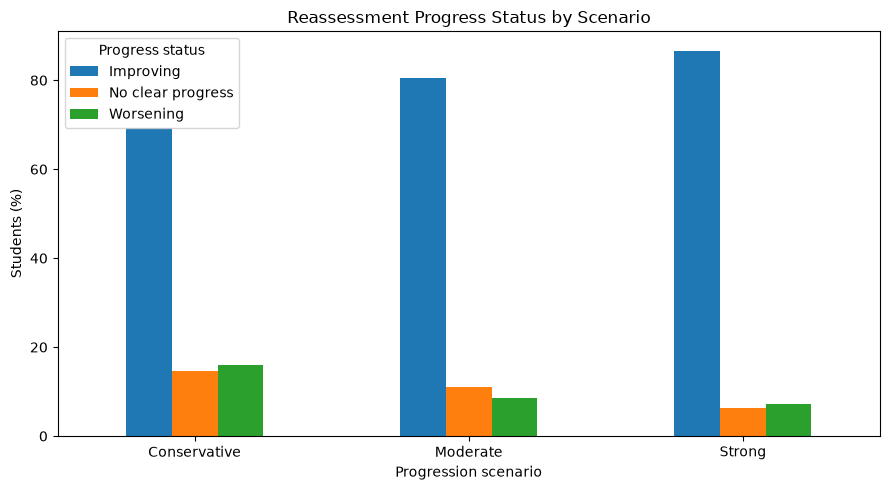

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\figures\reassessment_progress_status_distribution.png


In [18]:
progress_pivot = (
    progress_distribution
    .pivot(
        index="scenario",
        columns="progress_status",
        values="percentage",
    )
    .fillna(0)
)

progress_pivot = progress_pivot.reindex(
    scenario_order
)

progress_pivot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.xlabel("Progression scenario")
plt.ylabel("Students (%)")
plt.title("Reassessment Progress Status by Scenario")
plt.xticks(rotation=0)
plt.legend(title="Progress status")
plt.tight_layout()

PROGRESS_STATUS_FIGURE = (
    FIGURES_DIR
    / "reassessment_progress_status_distribution.png"
)

plt.savefig(
    PROGRESS_STATUS_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    PROGRESS_STATUS_FIGURE,
)

## 20. Save outputs

The notebook saves the detailed simulation results, student reassessment summaries, overall results, mentor follow up outputs, evaluation metrics, and the final simulation rules.


In [19]:
RUN_FILE = OUTPUT_DIR / "simulation_run_results.csv"
STUDENT_FILE = OUTPUT_DIR / "student_reassessment_summary.csv"
OVERALL_FILE = OUTPUT_DIR / "overall_reassessment_summary.csv"
EVALUATION_FILE = OUTPUT_DIR / "reassessment_evaluation_metrics.csv"
MENTOR_FOLLOWUP_FILE = OUTPUT_DIR / "mentor_follow_up_summary.csv"
MENTOR_EVALUATION_FILE = OUTPUT_DIR / "mentor_reassessment_evaluation.csv"
PROGRESS_DISTRIBUTION_FILE = OUTPUT_DIR / "progress_status_distribution.csv"
RULES_FILE = OUTPUT_DIR / "peer_based_simulation_rules.json"

simulation_runs.to_csv(RUN_FILE, index=False)
student_reassessment.to_csv(STUDENT_FILE, index=False)
overall_summary.to_csv(OVERALL_FILE, index=False)
reassessment_evaluation.to_csv(EVALUATION_FILE, index=False)
mentor_follow_up_table.to_csv(MENTOR_FOLLOWUP_FILE, index=False)
mentor_reassessment_evaluation.to_csv(MENTOR_EVALUATION_FILE, index=False)
progress_distribution.to_csv(PROGRESS_DISTRIBUTION_FILE, index=False)

rules_record = {
    "experimental_intervention_selection":
        "Rank 1 proposed intervention from Notebook 05",
    "simulations_per_student_per_scenario":
        N_SIMULATIONS,
    "peer_reference":
        "Not at risk training students only",
    "peer_hierarchy": [
        "Same programme and year level",
        "Same programme",
        "All not at risk training students",
    ],
    "scenario_strengths":
        SCENARIOS,
    "intervention_features":
        INTERVENTION_FEATURES,
    "joint_plausibility_method":
        "Nearest neighbour distance in training fitted scaled numeric and one hot categorical space",
    "plausibility_threshold":
        PLAUSIBILITY_THRESHOLD,
    "note":
        "Scenario strengths are study defined assumptions and do not represent causal intervention effect sizes.",
}

with open(
    RULES_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        rules_record,
        file,
        indent=2,
    )

print("Saved:", RUN_FILE)
print("Saved:", STUDENT_FILE)
print("Saved:", OVERALL_FILE)
print("Saved:", EVALUATION_FILE)
print("Saved:", MENTOR_FOLLOWUP_FILE)
print("Saved:", MENTOR_EVALUATION_FILE)
print("Saved:", PROGRESS_DISTRIBUTION_FILE)
print("Saved:", RULES_FILE)

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\reassessment\simulation_run_results.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\reassessment\student_reassessment_summary.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\reassessment\overall_reassessment_summary.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\reassessment\reassessment_evaluation_metrics.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\reassessment\mentor_follow_up_summary.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Taj

## Notebook 06 complete

The reassessment layer now evaluates student progression using a bootstrap based mentor follow up design.

The later prototype will replace the Rank 1 experimental assumption with actual mentor selection of one or multiple intervention plans and real later Banner and Moodle snapshots.